<a href="https://colab.research.google.com/github/youssef-bendhaou/deep_learning/blob/image-classification/fashion_mnist_gpu_benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


In [ ]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
train_images.shape

(60000, 28, 28)

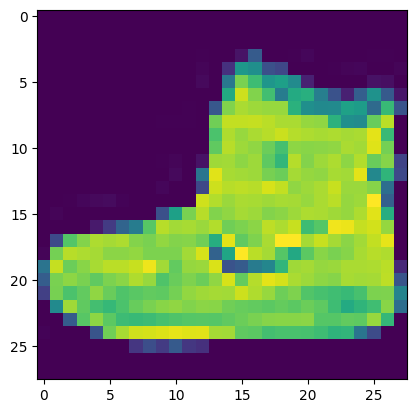

In [ ]:
plt.imshow(train_images[0])

In [ ]:
train_labels[0]

np.uint8(9)

In [ ]:
class_names[train_labels[0]]

'Ankle boot'

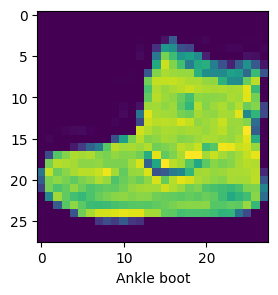

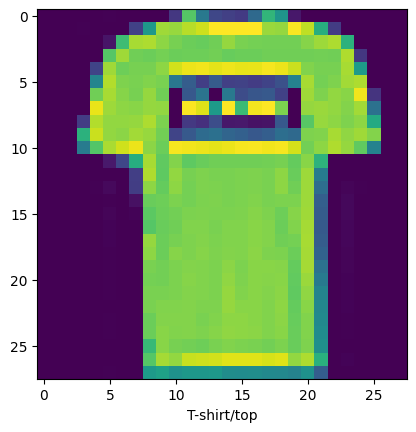

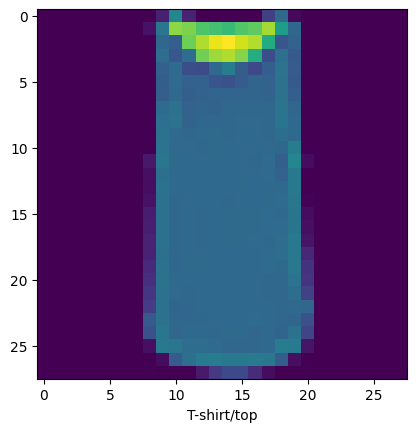

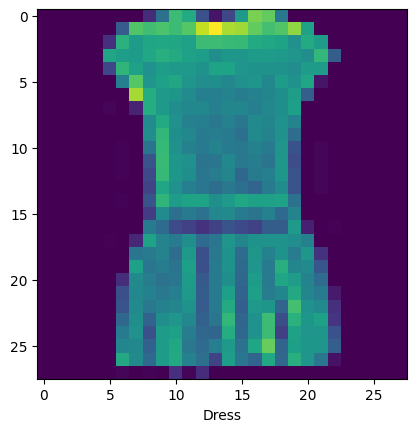

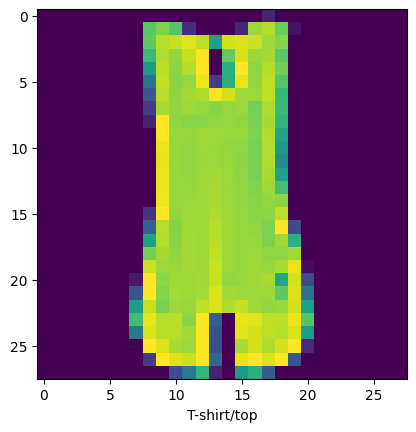

In [ ]:
plt.figure(figsize=(3,3))
for i in range(5):
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i]])
    plt.show()

In [ ]:
train_images_scaled = train_images / 255.0
test_images_scaled = test_images / 255.0

In [ ]:
def get_model(hidden_layers=1):
    layers = []
    # Your code goes here-----------START
    # Create Flatten input layers
    # Create hidden layers that are equal to hidden_layers argument in this function
    # Create output
    # Your code goes here-----------END
    layers = [keras.layers.Flatten(input_shape=(28, 28))]
    for i in range(hidden_layers):
        layers.append(keras.layers.Dense(500, activation='relu'),)
    # output layer
    layers.append(keras.layers.Dense(10, activation='sigmoid'))

    model = keras.Sequential(layers)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
model = get_model(1)
model.fit(train_images_scaled, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8314 - loss: 0.4766
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8672 - loss: 0.3607
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8816 - loss: 0.3223
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8912 - loss: 0.2978
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8944 - loss: 0.2824


In [ ]:
model.predict(test_images_scaled)[2]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.2881895e-02, 9.9999982e-01, 5.3043220e-07, 3.9936015e-03,
       3.6817081e-03, 1.1667266e-10, 5.6901975e-03, 1.9729671e-12,
       1.1720520e-05, 6.4753536e-09], dtype=float32)

In [ ]:
test_labels[2]

np.uint8(1)

In [ ]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

<h4 style="color:purple">5 Epochs performance comparison for 1 hidden layer</h4>

In [ ]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    model = get_model(1)
    model.fit(train_images_scaled, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8309 - loss: 0.4726
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8699 - loss: 0.3569
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8821 - loss: 0.3226
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8892 - loss: 0.3003
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8962 - loss: 0.2777
1min 9s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    model = get_model(1)
    model.fit(train_images_scaled, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8296 - loss: 0.4733
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8701 - loss: 0.3578
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8810 - loss: 0.3221
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8881 - loss: 0.3015
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8961 - loss: 0.2799
1min 14s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


<h4 style="color:purple">5 Epocs performance comparison with 5 hidden layers</h4>

In [ ]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    model = get_model(5)
    model.fit(train_images_scaled, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.8151 - loss: 0.5139
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.8608 - loss: 0.3880
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.8726 - loss: 0.3535
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.8822 - loss: 0.3234
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.8887 - loss: 0.3063
3min 20s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    model = get_model(5)
    model.fit(train_images_scaled, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.8134 - loss: 0.5165
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.8573 - loss: 0.3949
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.8726 - loss: 0.3531
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.8826 - loss: 0.3249
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.8866 - loss: 0.3117
3min 14s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
import time
import matplotlib.pyplot as plt

results = {}

configs = [
    ('CPU_1_layer', '/CPU:0', 1),
    ('GPU_1_layer', '/GPU:0', 1),
    ('CPU_5_layer', '/CPU:0', 5),
    ('GPU_5_layer', '/GPU:0', 5),
]

for name, device, layers in configs:
    start = time.time()
    with tf.device(device):
        model = get_model(layers)
        model.fit(train_images_scaled, train_labels, epochs=5, verbose=0)
    results[name] = time.time() - start

# Plot
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Configuration")
plt.ylabel("Temps (secondes)")
plt.title("Comparaison CPU vs GPU et nombre de couches")
plt.xticks(rotation=30)
plt.show()